In [24]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

from overseec.modules.semseg import *
from overseec.modules.mask_refiner import *
from overseec.overseec_config import AllConfig
from overseec.OVerSeeC import OVerSeeC

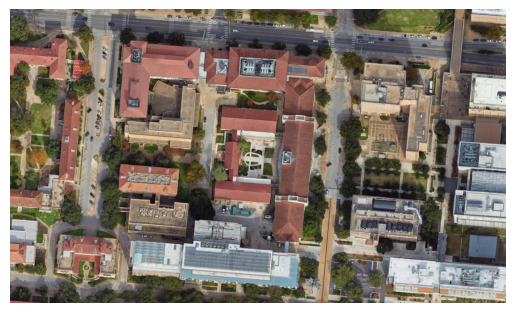

In [25]:
map_name = "ahg"
MR_prefix = "samrefiner"
# prompt_prefix = "prompt_3"
sam_model_prefix = "vit_h"
cuda_device = "cuda:7"
sat_img_path = f"/scratch/rwik/SARA/molmo_testing/geotiffs/tiffs/{map_name}.tif"
sat_img = cv2.imread(sat_img_path)

plt.imshow(sat_img[..., ::-1])
plt.axis("off")
plt.show()

In [26]:
def mask_and(mask1: np.ndarray, mask2: np.ndarray) -> np.ndarray:
    return np.logical_and(mask1, mask2).astype(np.uint8)

def mask_or(mask1: np.ndarray, mask2: np.ndarray) -> np.ndarray:
    return np.logical_or(mask1, mask2).astype(np.uint8)

def mask_not(mask: np.ndarray) -> np.ndarray:
    return np.logical_not(mask).astype(np.uint8)

def mask_remove(mask1: np.ndarray, mask2: np.ndarray) -> np.ndarray:
    return (mask1 & ~mask2).astype(np.uint8)


def generate_costmap(mask_dict):
    shape = next(iter(mask_dict.values())).shape

    device = next(iter(mask_dict.values())).device
    road_logit = mask_dict.get('road', torch.zeros(shape, dtype=torch.float32, device=device))
    trees_logit = mask_dict.get('tree', torch.zeros(shape, dtype=torch.float32, device=device))
    buildings_logit = mask_dict.get('building', torch.zeros(shape, dtype=torch.float32, device=device))
    grass_logit = mask_dict.get('grass', torch.zeros(shape, dtype=torch.float32, device=device))
    trail_logit = mask_dict.get('trail or footway', torch.zeros(shape, dtype=torch.float32, device=device))
    water_logit = mask_dict.get('water', torch.zeros(shape, dtype=torch.float32, device=device))
    # river_logit = mask_dict.get('river', torch.zeros(shape, dtype=torch.float32))
    baseball_field_logit = mask_dict.get('baseball field', torch.zeros(shape, dtype=torch.float32, device=device))

    road_mask = road_logit > 0.4
    trail_mask = trail_logit > 0.4
    grass_mask = grass_logit > 0.6  
    buildings_mask = buildings_logit > 0.6
    trees_mask = trees_logit > 0.6
    water_mask = water_logit > 0.6
    baseball_field_mask = baseball_field_logit > 0.6
    

    # Unknown Mask
    mask_count = road_mask.to(torch.float32) + trail_mask.to(torch.float32) + grass_mask.to(torch.float32) + \
                 buildings_mask.to(torch.float32) + trees_mask.to(torch.float32) + water_mask.to(torch.float32) + baseball_field_mask.to(torch.float32)

    data_region = (mask_count > 0)
    data_region_float = data_region.to(torch.float32)

    # Heirarchy
    # grass_mask = mask_remove(grass_mask, baseball_field_mask)
    grass_mask = grass_mask & ~baseball_field_mask
    # Geometry
    # Nothing for now


    costmap = torch.zeros(shape, dtype=torch.float32, device=device)
    costmap[road_mask] += 0 * road_logit[road_mask]
    costmap[trail_mask] += 0 * trail_logit[trail_mask]
    costmap[grass_mask] += 300 * grass_logit[grass_mask]
    costmap[buildings_mask] += 2000 * buildings_logit[buildings_mask]
    costmap[trees_mask] += 2000 * trees_logit[trees_mask]
    costmap[water_mask] += 2000 * water_logit[water_mask]
    costmap[baseball_field_mask] += 2000 * baseball_field_logit[baseball_field_mask]

    costmap[data_region] = costmap[data_region] / mask_count[data_region]

    costmap += costmap.max() * (1 - data_region_float)  # Assign high cost to non-data regions


    return costmap


In [27]:
overseec_clipseg_classes = {
    "road": (128, 64, 128),
    "trail or footway": (244, 35, 232),
    "tree": (0, 128, 0),
    "grass": (0, 128, 128),
    "building": (0, 0, 128),
    "water": (0, 0, 255),
    # "baseball field": (107, 142, 35),
}

overseec_clipseg_classes_semseg_knobs = {
    "road": 0.3,
    "trail or footway": 0.3,
    "tree": 0.8,
    "grass": 0.8,
    "building": 0.8,
    "water": 0.8,
    # "baseball field": 0.8,
}

semseg_tile_size = (512, 512)
semseg_stride = 256
semseg_tile_combine_method = "max"

mask_refiner_tile_size = (512, 512)
mask_refiner_stride = 256
mask_refiner_tile_combine_method = "mean"


overseec_clipseg_config = AllConfig(
    model_ckpt = "xyz",
    model_name = "clipseg",
    mask_refiner_name= "samrefiner",

    classes=overseec_clipseg_classes,
    classes_semseg_knobs=overseec_clipseg_classes_semseg_knobs,

    semseg_tile_size = semseg_tile_size,
    semseg_stride = semseg_stride,
    semseg_tile_combine_method= semseg_tile_combine_method,

    mask_refiner_tile_size = mask_refiner_tile_size,
    mask_refiner_stride = mask_refiner_stride,
    mask_refiner_tile_combine_method = mask_refiner_tile_combine_method,
    use_negative_points= True,

    sam_model= sam_model_prefix,

    sam_device= cuda_device,
    cmap_device= cuda_device,
    semseg_device= cuda_device,


)

overseec_clipseg_config.reset()

overseec_clipseg = OVerSeeC(
    config=overseec_clipseg_config
)

In [28]:
clipseg_sigmoid_mask_refiner_logits, clipseg_mask_refiner_logits_map, clipseg_mask_refiner_logits_tiled, clipseg_sigmoid_semseg_logits, semseg_logits_map = overseec_clipseg(sat_img_path, sat_img)




Semantic Segmentation ..... 


Cropping Image Patches:   0%|          | 0/220 [00:00<?, ?it/s]

semseg:   0%|          | 0/14 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/scratch/rwik/miniconda3/envs/vllm/lib/python3.10/site-packages/transformers/image_processing_utils.py:44: UserWarning: The following named arguments are not valid for `ViTImageProcessor.preprocess` and were ignored: 'padding', 'truncation'
  return self.preprocess(images, **kwargs)
semseg: 100%|█████████




Mask Refiner ..... 


Mask refiner:   0%|          | 0/220 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PA

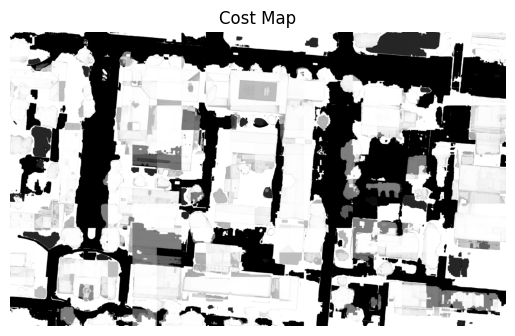

In [29]:
clipseg_MR_general_masks = {}
class_names = list(overseec_clipseg_config.classes.keys())
for idx in range(len(class_names)):
    clipseg_MR_general_masks[class_names[idx]] = clipseg_sigmoid_mask_refiner_logits[idx]

clipseg_costmap = generate_costmap(clipseg_MR_general_masks)
clipseg_costmap = clipseg_costmap.cpu().numpy()
plt.imshow(clipseg_costmap, cmap='gray')
plt.title("Cost Map")
plt.axis('off')
plt.show()

In [30]:
overseec_segformer_classes = {
    "road": (128, 64, 128),
    "tree": (0, 128, 0),
    "grass": (0, 128, 128),
    "building": (0, 0, 128),
    "trail or footway": (244, 35, 232),
    "water": (0, 0, 255),
    # "baseball field": (107, 142, 35),
}

overseec_segformer_classes_semseg_knobs = {
    "road": 0.3,
    "tree": 0.3,
    "grass": 0.8,
    "building": 0.8,
    "trail or footway": 0.8,
    "water": 0.8,
    # "baseball field": 0.6,
}

semseg_tile_size = (512, 512)
semseg_stride = 256
semseg_tile_combine_method = "max"

mask_refiner_tile_size = (512, 512)
mask_refiner_stride = 256
mask_refiner_tile_combine_method = "mean"


overseec_segformer_config = AllConfig(
    model_ckpt = "/scratch/rwik/SARA/molmo_testing/training_scripts/checkpoints/segformer_unified_dataset_new_2/traversability-epoch=84.ckpt",
    model_name = "segformer",
    mask_refiner_name= "samrefiner",

    classes=overseec_segformer_classes,
    classes_semseg_knobs=overseec_segformer_classes_semseg_knobs,

    semseg_tile_size = semseg_tile_size,
    semseg_stride = semseg_stride,
    semseg_tile_combine_method= semseg_tile_combine_method,

    mask_refiner_tile_size = mask_refiner_tile_size,
    mask_refiner_stride = mask_refiner_stride,
    mask_refiner_tile_combine_method = mask_refiner_tile_combine_method,
    use_negative_points= True,

    sam_model= sam_model_prefix,

    sam_device= cuda_device,
    cmap_device= cuda_device,
    semseg_device= cuda_device,
    


)

overseec_segformer_config.reset()

overseec_segformer = OVerSeeC(
    config=overseec_segformer_config
)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([6, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [31]:
segformer_sigmoid_mask_refiner_logits, segformer_mask_refiner_logits_map, segformer_mask_refiner_logits_tiled, segformer_sigmoid_semseg_logits, semseg_logits_map = overseec_segformer(sat_img_path, sat_img)




Semantic Segmentation ..... 


semseg:   0%|          | 0/14 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
semseg: 100%|██████████| 14/14 [00:17<00:00,  1.26s/it]





Mask Refiner ..... 


Mask refiner:   0%|          | 0/220 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PA

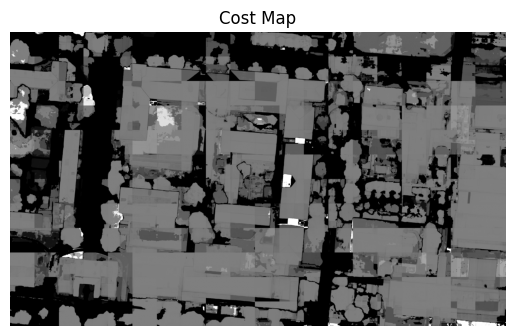

In [32]:
segformer_MR_general_masks = {}
class_names = list(overseec_segformer_config.classes.keys())
for idx in range(len(class_names)):
    segformer_MR_general_masks[class_names[idx]] = segformer_sigmoid_mask_refiner_logits[idx]

segformer_costmap = generate_costmap(segformer_MR_general_masks)
segformer_costmap = segformer_costmap.cpu().numpy()

# print(overseec_segformer_config.semseg_config.default_classes)
plt.imshow(segformer_costmap, cmap='gray')
plt.title("Cost Map")
plt.axis('off')
plt.show()

In [33]:
overseec_dinounet_classes = {
    "road": (128, 64, 128),
    "tree": (0, 128, 0),
    "grass": (0, 128, 128),
    "building": (0, 0, 128),
    "trail or footway": (244, 35, 232),
    "water": (0, 0, 255),
    # "baseball field": (107, 142, 35),
}

overseec_dinounet_classes_semseg_knobs = {
    "road": 0.3,
    "tree": 0.3,
    "grass": 0.8,
    "building": 0.8,
    "trail or footway": 0.8,
    "water": 0.8,
    # "baseball field": 0.6,
}

semseg_tile_size = (512, 512)
semseg_stride = 256
semseg_tile_combine_method = "max"

mask_refiner_tile_size = (512, 512)
mask_refiner_stride = 256
mask_refiner_tile_combine_method = "mean"


overseec_dinounet_config = AllConfig(
    model_ckpt = "/scratch/rwik/SARA/molmo_testing/training_scripts/checkpoints/dinounet_unified_dataset_new_2/traversability-epoch=84.ckpt",
    model_name = "dinounet",
    mask_refiner_name= "samrefiner",

    classes=overseec_dinounet_classes,
    classes_semseg_knobs=overseec_dinounet_classes_semseg_knobs,

    semseg_tile_size = semseg_tile_size,
    semseg_stride = semseg_stride,
    semseg_tile_combine_method= semseg_tile_combine_method,

    mask_refiner_tile_size = mask_refiner_tile_size,
    mask_refiner_stride = mask_refiner_stride,
    mask_refiner_tile_combine_method = mask_refiner_tile_combine_method,
    use_negative_points= True,

    sam_model= sam_model_prefix,

    sam_device= cuda_device,
    cmap_device= cuda_device,
    semseg_device= cuda_device,
    


)

overseec_dinounet_config.reset()

overseec_dinounet = OVerSeeC(
    config=overseec_dinounet_config
)

Using cache found in /home/rwik2000/.cache/torch/hub/facebookresearch_dino_main


In [34]:
dinounet_sigmoid_mask_refiner_logits, dinounet_mask_refiner_logits_map, dinounet_mask_refiner_logits_tiled, dinounet_sigmoid_semseg_logits, dinounet_semseg_logits_map = overseec_dinounet(sat_img_path, sat_img)




Semantic Segmentation ..... 


semseg:   0%|          | 0/14 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
semseg: 100%|██████████| 14/14 [00:30<00:00,  2.17s/it]





Mask Refiner ..... 


Mask refiner:   0%|          | 0/220 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PA

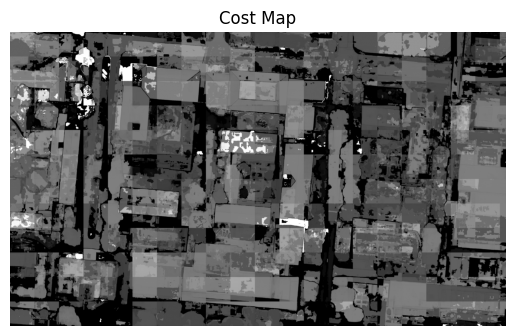

In [35]:
dinounet_MR_general_masks = {}
class_names = list(overseec_dinounet_config.classes.keys())
for idx in range(len(class_names)):
    dinounet_MR_general_masks[class_names[idx]] = dinounet_sigmoid_mask_refiner_logits[idx]

dinounet_costmap = generate_costmap(dinounet_MR_general_masks)
dinounet_costmap = dinounet_costmap.cpu().numpy()

# print(overseec_dinounet_config.semseg_config.default_classes)
plt.imshow(dinounet_costmap, cmap='gray')
plt.title("Cost Map")
plt.axis('off')
plt.show()

In [36]:
import gc
del overseec_clipseg
del overseec_segformer
del overseec_dinounet
torch.cuda.empty_cache()
gc.collect()

2813

In [37]:
import sys
sys.path.append("/scratch/rwik/SARA/molmo_testing/overseec/modules/planners/")
# satellite_cmap_scripts/planner_tests/planners
import astar_bind

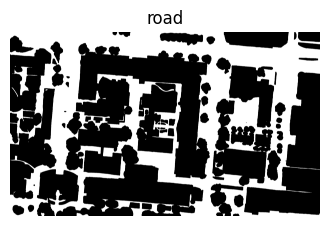

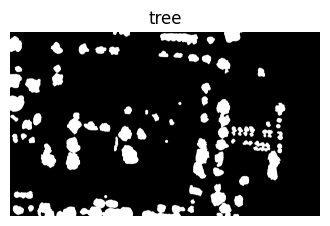

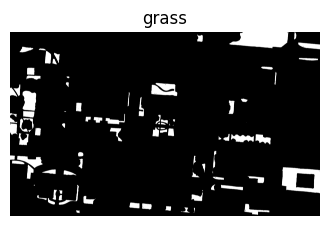

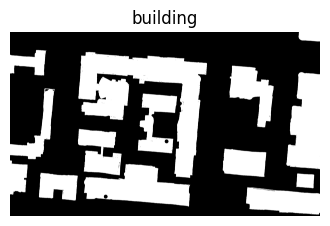

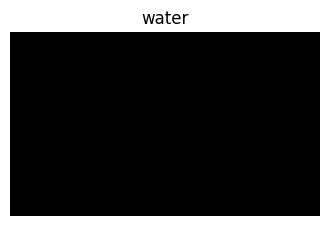

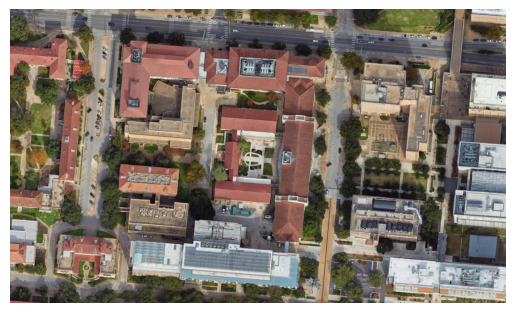

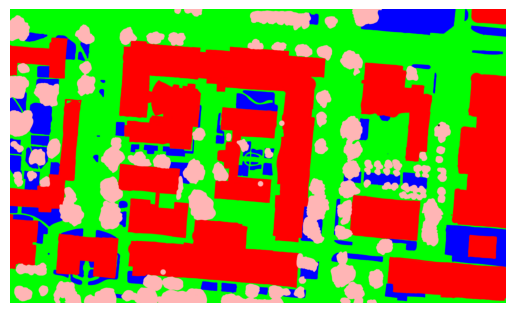

In [38]:
gt_semantic_map_path = f"/scratch/rwik/SARA/molmo_testing/costmap/{map_name}_costmap_resized.png"
tgt_cmap_file = f"/scratch/rwik/SARA/molmo_testing/geotiffs/costmap/{map_name}_costmap_resized.png"
tgt_costmap_color = cv2.imread(tgt_cmap_file)
sat_img = cv2.imread(sat_img_path)

tgt_classes = {
    "road" : (1, 255, 0),
    "tree" : (182, 181, 255),
    "grass" : (254, 0, 0),
    "building" : (0, 0, 254),
    "water":    (0,127,254),

    # "baseball field" : (181, 0, 193),
}

tgt_masks_dict = {}
tgt_masks = []
tgt_masks_dict_torch = {}
tgt_masks_torch = []

for cls, color_bgr in tgt_classes.items():
    # compute bounds with clipping
    lower = np.clip(np.array(color_bgr, dtype=int) - 5, 0, 255).astype(np.uint8)
    upper = np.clip(np.array(color_bgr, dtype=int) + 5, 0, 255).astype(np.uint8)

    mask = cv2.inRange(tgt_costmap_color, lower, upper)
    mask = (mask > 0).astype(np.uint8)
    tgt_masks_dict[cls] = mask
    tgt_masks.append(mask)
    tgt_masks_dict_torch[cls] = torch.tensor(mask)
    tgt_masks_torch.append(torch.tensor(mask))


    # display
    plt.figure(figsize=(4,4))
    plt.imshow(mask, cmap='gray')
    plt.title(cls)
    plt.axis('off')
    plt.show()

tgt_masks = np.array(tgt_masks)

plt.imshow(sat_img[...,::-1])
plt.axis('off')  # Turn off axis ticks
plt.show()

plt.imshow(tgt_costmap_color[...,::-1])
plt.axis('off')  # Turn off axis ticks
plt.show()

In [39]:
def generate_cpp_inputs_from_masks(tgt_masks_dict, rank_dict, classes, H, W):
    """
    Converts masks and rank_dict into:
    - semantic_map: H x W np.ndarray[int32] where each pixel has a class ID
    - cpp_rank_dict: dict[int -> int] mapping class ID to rank
    """
    # 1. Map class names to unique integer IDs
    class_to_id = {cls: idx for idx, cls in enumerate(classes)}

    # 2. Build semantic map (default = -1 for unknown class)
    semantic_map = np.zeros((H, W), dtype=np.int32)

    for cls, mask in tgt_masks_dict.items():
        cls_id = class_to_id[cls]
        semantic_map += cls_id * mask

    # 3. Convert rank dict using class IDs
    cpp_rank_dict = {class_to_id[cls]: rank for cls, rank in rank_dict.items()}

    return semantic_map, cpp_rank_dict

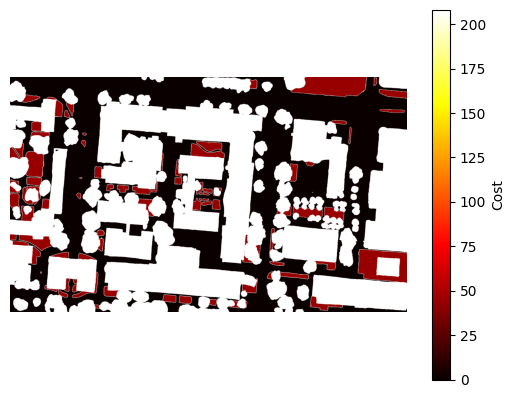

In [40]:
costmap_gt = generate_costmap(tgt_masks_dict_torch)
plt.imshow(costmap_gt.cpu().numpy(),cmap="hot")
plt.colorbar(label='Cost')
plt.axis('off')  # Turn off axis ticks
plt.show()

H, W = costmap_gt.shape

rank_dict = {
    "road": 1,
    "grass": 2,
    "tree": 3,
    "building": 4,
    "water": 5,
    
}

semantic_map_gt, cpp_rank_dict_gt = generate_cpp_inputs_from_masks(
    tgt_masks_dict=tgt_masks_dict,
    rank_dict=rank_dict,
    classes=tgt_classes,
    H=H,
    W=W
)


In [41]:
def plot_paths(img, paths_dict, circle_radius=20, spacing=20):
    H, W, C = img.shape
    n = len(paths_dict)

    result_images = []

    # Create individual annotated images
    for label, path in paths_dict.items():
        img_copy = img.copy()
        for (x, y) in path:
            img_copy = cv2.circle(img_copy, (x, y), circle_radius, (0, 255, 0), -1)
        result_images.append((label, img_copy))


    # Create one long image with spacing
    spacer = np.ones((H, spacing, C), dtype=np.uint8) * 255
    spaced_images = []
    for i, (_, im) in enumerate(result_images):
        spaced_images.append(im)
        if i < n - 1:
            spaced_images.append(spacer)

    final_concat = np.concatenate(spaced_images, axis=1)
    return final_concat


def rank_pixel_path_integral(path, semantic_map, rank_dict):
    cost = 0
    for x, y in path:
        cls = semantic_map[y, x]
        if cls in rank_dict:
            rank = rank_dict[cls]
            cost += rank - 1
    return cost

In [42]:
# Fixed: Removed the invalid line with natural language text

import os
import random
import numpy as np
import shutil
from tqdm import tqdm

# ----------------- Setup -----------------
seed = 42

def generate_random_start_goal_pairs(H, W, num_pairs=100, seed=seed):
    rng = np.random.default_rng(seed)
    starts = rng.integers(low=0, high=(W, H), size=(num_pairs, 2))
    goals = rng.integers(low=0, high=(W, H), size=(num_pairs, 2))
    return list(zip(map(tuple, starts), map(tuple, goals)))

def rank_pixel_path_integral(path, semantic_map, rank_dict):
    cost = 0
    for x, y in path:
        cls = semantic_map[y, x]
        if cls in rank_dict:
            cost += rank_dict[cls] - 1
    return cost

def costmap_path_integral(path, costmap):
    return sum(costmap[y, x] for x, y in path)

def compute_relative_ordering_accuracy_from_costmaps(costmaps_dict, num_pairs=1000, seed=42, ignore_ties=True):
    """
    Computes relative ordering accuracy across multiple costmaps using randomly sampled point pairs.

    Args:
        costmaps_dict (dict): Keys like 'gt', 'clipseg', etc. Each value is a 2D numpy array (H, W).
        num_pairs (int): Number of random point pairs to sample.
        seed (int): Random seed for reproducibility.
        ignore_ties (bool): If True, skip GT-equal pairs.

    Returns:
        accuracy_dict (dict): % accuracy for each method vs. GT.
    """
    rng = np.random.default_rng(seed)
    h, w = next(iter(costmaps_dict.values())).shape
    methods = [k for k in costmaps_dict if k != "gt"]
    correct_counts = {method: 0 for method in methods}
    total_counts = {method: 0 for method in methods}

    for _ in range(num_pairs):
        yx1 = rng.integers(low=[0, 0], high=[h, w])
        yx2 = rng.integers(low=[0, 0], high=[h, w])
        y1, x1 = yx1
        y2, x2 = yx2

        gt1, gt2 = costmaps_dict["gt"][y1, x1], costmaps_dict["gt"][y2, x2]
        if ignore_ties and gt1 == gt2:
            continue

        for method in methods:
            c1 = costmaps_dict[method][y1, x1]
            c2 = costmaps_dict[method][y2, x2]
            if (gt1 < gt2 and c1 < c2) or (gt1 > gt2 and c1 > c2) or (gt1 == gt2 and c1 == c2):
                correct_counts[method] += 1
            total_counts[method] += 1

    accuracy_dict = {
        method: (100 * correct_counts[method] / total_counts[method]) if total_counts[method] > 0 else 0.0
        for method in methods
    }

    return accuracy_dict



In [43]:
# --------- Main Evaluation Script ---------
NUM_PAIRS = 100
H, W = sat_img.shape[:2]
start_goal_pairs = generate_random_start_goal_pairs(H, W, NUM_PAIRS)

parent_dir = f"results/{map_name}_{sam_model_prefix}_{MR_prefix}"
images_dir = os.path.join(parent_dir, "images")
start_end_dir = os.path.join(parent_dir, "start_end_images")
planned_paths_dir = os.path.join(parent_dir, "paths")

if os.path.exists(parent_dir):
    if os.path.exists(images_dir):
        shutil.rmtree(images_dir)
    if os.path.exists(start_end_dir):
        shutil.rmtree(start_end_dir)
    if os.path.exists(planned_paths_dir):
        shutil.rmtree(planned_paths_dir)
os.makedirs(images_dir, exist_ok=True)
os.makedirs(start_end_dir, exist_ok=True)
os.makedirs(planned_paths_dir, exist_ok=True)

methods = ["gt", "clipseg", "dinounet", "segformer"]

rank_regret_dict = {k: [] for k in methods}
lengths_dict = {k: [] for k in methods}
gt_cost_on_pred_costmaps = {k: [] for k in methods}

for idx, (start, goal) in enumerate(tqdm(start_goal_pairs, desc="Evaluating")):
    paths = {
        "gt": astar_bind.astar(costmap_gt, *start, *goal),
        "clipseg": astar_bind.astar(clipseg_costmap, *start, *goal),
        "dinounet": astar_bind.astar(dinounet_costmap, *start, *goal),
        "segformer": astar_bind.astar(segformer_costmap, *start, *goal)
    }

    for k in methods:
        np.save(f"{planned_paths_dir}/{idx:04d}_{k}.npy", paths[k])
        lengths_dict[k].append(len(paths[k]))

    # Plotting and saving
    path_imgs = plot_paths(sat_img, {
        "ground truth": paths["gt"],
        "clipseg": paths["clipseg"],
        "dinounet": paths["dinounet"],
        "segformer": paths["segformer"]
    }, circle_radius=20, spacing=100)

    start_end_img = cv2.circle(sat_img.copy(), start, 30, (255, 0, 0), -1)
    start_end_img = cv2.circle(start_end_img, start, 70, (255, 0, 0), 10)
    start_end_img = cv2.circle(start_end_img, goal, 30, (0, 0, 255), -1)
    start_end_img = cv2.circle(start_end_img, goal, 70, (0, 0, 255), 10)

    cv2.imwrite(os.path.join(images_dir, f"{idx:04d}.png"), path_imgs)
    cv2.imwrite(os.path.join(start_end_dir, f"{idx:04d}.png"), start_end_img)

    # Rank-based regret metric
    rank_regret_dict["gt"].append(rank_pixel_path_integral(paths["gt"], semantic_map_gt, cpp_rank_dict_gt))
    rank_regret_dict["clipseg"].append(rank_pixel_path_integral(paths["clipseg"], semantic_map_gt, cpp_rank_dict_gt))
    rank_regret_dict["dinounet"].append(rank_pixel_path_integral(paths["dinounet"], semantic_map_gt, cpp_rank_dict_gt))
    rank_regret_dict["segformer"].append(rank_pixel_path_integral(paths["segformer"], semantic_map_gt, cpp_rank_dict_gt))

    # Cost of GT path on predicted maps
    gt_cost_on_pred_costmaps["gt"].append(costmap_path_integral(paths["gt"], costmap_gt))
    gt_cost_on_pred_costmaps["clipseg"].append(costmap_path_integral(paths["clipseg"], costmap_gt))
    gt_cost_on_pred_costmaps["dinounet"].append(costmap_path_integral(paths["dinounet"], costmap_gt))
    gt_cost_on_pred_costmaps["segformer"].append(costmap_path_integral(paths["segformer"], costmap_gt))


Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 100/100 [14:37<00:00,  8.77s/it]


In [44]:

# -------- Summary & Metrics ----------
costmaps_dict = {
    "gt": costmap_gt,
    "clipseg": clipseg_costmap,
    "dinounet": dinounet_costmap,
    "segformer": segformer_costmap,
}
accuracy_dict = compute_relative_ordering_accuracy_from_costmaps(costmaps_dict, num_pairs=100000)
accuracy_dict["gt"] = 100.0  # GT is always perfect


In [45]:

print("\n📊 Average Cost of Paths under GT Costmap:")
# print(f"  {'GT':<10}: {np.mean([costmap_path_integral(paths['gt'], costmap_gt) for paths in paths.values()]):.2f}")

mean_costs_dict = {}
for method in ["gt","clipseg", "dinounet", "segformer"]:
    mean_cost = np.mean(gt_cost_on_pred_costmaps[method])
    mean_costs_dict[method] = mean_cost
    print(f"  {method.title():<10}: {mean_cost:.2f}")



📊 Average Cost of Paths under GT Costmap:
  Gt        : 15197.68
  Clipseg   : 150517.84
  Dinounet  : 377211.84
  Segformer : 322914.69


/scratch/rwik/miniconda3/envs/vllm/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/scratch/rwik/miniconda3/envs/vllm/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/scratch/rwik/miniconda3/envs/vllm/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(
/scratch/rwik/miniconda3/envs/vllm/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


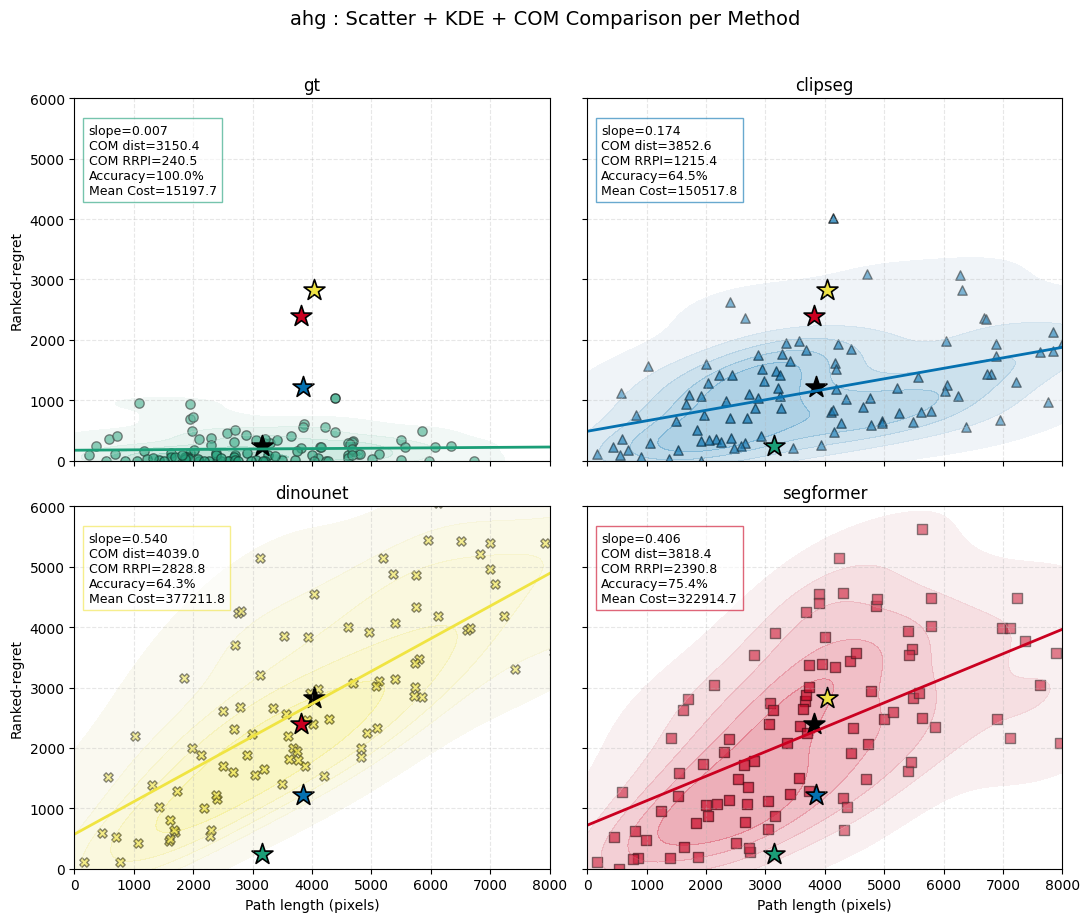

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde


lengths_gt = np.array(lengths_dict["gt"])
lengths_clipseg = np.array(lengths_dict["clipseg"])
lengths_dinounet = np.array(lengths_dict["dinounet"])
lengths_segformer = np.array(lengths_dict["segformer"])

rank_regret_gt = np.array(rank_regret_dict["gt"])
rank_regret_clipseg = np.array(rank_regret_dict["clipseg"])
rank_regret_dinounet = np.array(rank_regret_dict["dinounet"])
rank_regret_segformer = np.array(rank_regret_dict["segformer"])

gt_x,   gt_y   = lengths_gt, rank_regret_gt
clip_x, clip_y = lengths_clipseg, rank_regret_clipseg
dino_x, dino_y = lengths_dinounet, rank_regret_dinounet
seg_x,  seg_y  = lengths_segformer, rank_regret_segformer

method_data = {
    "gt": (gt_x,  gt_y,  "#1b9e77", "o"),
    "clipseg":     (clip_x, clip_y, "#0571b0", "^"),
    "dinounet":    (dino_x, dino_y, "#f0e442", "X"),
    "segformer":    (seg_x, seg_y, "#ca0020", "s"),
}

# Precompute COMs for all methods
com_dict = {}
for name, (xi, yi, colour, marker) in method_data.items():
    kde = gaussian_kde(np.vstack([xi, yi]))
    grid_x, grid_y = np.mgrid[0:8000:100j, 0:8000:100j]
    grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
    density = kde(grid_coords).reshape(grid_x.shape)
    total_density = density.sum()
    com_x = (grid_x * density).sum() / total_density
    com_y = (grid_y * density).sum() / total_density
    com_dict[name] = (com_x, com_y)

# ------------------ 4-panel figure --------------------------------
fig, axs = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)

for ax, (name, (xi, yi, colour, marker)) in zip(axs.flatten(), method_data.items()):

    # Scatter
    ax.scatter(xi, yi, color=colour, marker=marker, s=45,
               alpha=0.70, edgecolors="k", label=name)

    # Regression line
    m, b = np.polyfit(xi, yi, 1)
    xfit = np.linspace(0, 10000, 200)
    ax.plot(xfit, m * xfit + b, color=colour, lw=2)

    # KDE background
    sns.kdeplot(x=xi, y=yi,
                cmap=sns.light_palette(colour, as_cmap=True),
                fill=True, thresh=0.05, levels=6,
                alpha=0.35, linewidths=0.8, ax=ax)
    for other_name, (cx, cy) in com_dict.items():
        face_color = "k" if other_name == name else method_data[other_name][2]
        edge_color = "black"
        ax.scatter(cx, cy,
                   s=250, marker='*',
                   c=face_color,
                   edgecolors=edge_color,
                   linewidths=1.2,
                   label=f"COM {other_name}" if other_name != name else "COM (self)")

    # Text box (slope and self COM)
    com_x, com_y = com_dict[name]
    ax.text(0.03, 0.93,
            f"slope={m:.3f}\nCOM dist={com_x:.1f}\nCOM RRPI={com_y:.1f}\nAccuracy={accuracy_dict[name]:.1f}%\nMean Cost={mean_costs_dict[name]:.1f}",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=9, bbox=dict(fc="w", ec=colour, alpha=0.6))

    ax.set_title(name)
    ax.set_xlim(0, 8000)
    ax.set_ylim(0, 6000)
    ax.grid(ls="--", alpha=0.3)
    ax.set_xlabel("Path length (pixels)")
    ax.set_ylabel("Ranked-regret")

fig.suptitle(f"{map_name} : Scatter + KDE + COM Comparison per Method", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(f"{parent_dir}/scatter_kde_com_comparison.png", dpi=300, bbox_inches='tight')
plt.show()